# 02 · Model Training

Trains and evaluates a multiclass mood classifier using Spotify audio features.

| # | Section                              |
|---|--------------------------------------|
| 1 | Configuration — paths & constants    |
| 2 | Data loading & validation            |
| 3 | Train / test split                   |
| 4 | Model selection via cross-validation |
| 5 | Final training & evaluation          |
| 6 | Confusion matrix                     |
| 7 | Feature importances                  |
| 8 | Model serialization                  |

In [2]:
import pandas as pd
from pathlib import Path

# ML
import joblib
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

## 1. Configuration

All tunable constants live here — change once, apply everywhere.

In [4]:
# Paths
PROCESSED_PATH = Path("../data/processed/spotify_tracks_mood_clean.csv").resolve()
MODEL_PATH     = Path("../models/mood_classifier.pkl").resolve()
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Split & CV
RANDOM_STATE = 42
TEST_SIZE    = 0.20  # (20% del dataset para test).
CV_FOLDS     = 5     # The entire training/evaluation cycle 5 times with different partitions

# Feature set
FEATURES = [
    "valence", "energy", "danceability", "tempo",
    "acousticness", "instrumentalness", "loudness", "popularity",
]
TARGET = "mood"

## 2. Data Loading & Validation

In [5]:
df = pd.read_csv(PROCESSED_PATH)

print(f"Shape : {df.shape}")
print(f"NaN   : {df[FEATURES + [TARGET]].isna().sum().sum()}")
print()
print("Class distribution:")
dist = df[TARGET].value_counts(normalize=True).map("{:.1%}".format)
print(dist.to_string())

X = df[FEATURES]
y = df[TARGET]

Shape : (89740, 14)
NaN   : 0

Class distribution:
mood
happy        37.0%
energetic    33.7%
sad          21.2%
chill         8.1%


## 3. Train / Test Split

> `stratify=y` preserves class proportions in both sets, which is critical for imbalanced distributions.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (71792, 8)
Test  : (17948, 8)


## 4. Selection and comparison of models

In this section, several candidate classifiers are systematically compared using K-fold cross-validation on the training set (`X_train`, `y_train`). Each model is wrapped in a `Pipeline(StandardScaler → classifier)`, so that the scaling of the numerical variables is applied **within each fold** without information leakage (the scaler is fitted only with the training data of that fold and then applied to the test of the same fold).

The procedure is as follows:

1. Define a dictionary of candidate models (`KNN`, `RandomForest`, `GradientBoosting`), each with reasonable hyperparameters.
2. For each model:
    - Construct a `Pipeline` with `StandardScaler` followed by the classifier.
    - Perform stratified cross-validation with `CV_FOLDS` splits, using **F1 weighted** (`f1_weighted`) as the primary metric.
    - Record the following for each model:
    - Mean F1 in validation (`mean_f1`),
    - Standard deviation of F1 between folds (`std_f1`),
    - Mean training time (`fit_time`).
3. Consolidate the results into a `DataFrame` (`results_df`), ordering the models from highest to lowest mean F1.
4. Automatically select the winning model using `idxmax()` on the `mean_f1` column, saving its name in `best_name`.

This way, the model selection is not based on subjective impressions, but on a reproducible benchmark across multiple partitions of the training set, controlling for the metric of interest (weighted F1) and also considering the stability and computational cost of each alternative.


In [7]:
candidates = {
    "KNN"             : KNeighborsClassifier(n_neighbors=11),
    "RandomForest"    : RandomForestClassifier(
                            n_estimators=100,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                        ),
    "GradientBoosting": GradientBoostingClassifier(
                            n_estimators=100,
                            random_state=RANDOM_STATE,
                        ),
}

rows = {}
for name, clf in candidates.items():
    pipe   = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    cv     = cross_validate(
        pipe, X_train, y_train,
        cv=CV_FOLDS,
        scoring="f1_weighted",
        n_jobs=-1,
        return_train_score=False,
    )
    rows[name] = {
        "mean_f1" : cv["test_score"].mean(),
        "std_f1"  : cv["test_score"].std(),
        "fit_time": cv["fit_time"].mean(),
    }

results_df = (
    pd.DataFrame(rows).T
      .sort_values("mean_f1", ascending=False)
)
print(results_df.to_string(float_format="{:.4f}".format))

best_name = results_df["mean_f1"].idxmax()
print(f"\n\u2705  Winner: {best_name}  "
      f"(F1 = {results_df.loc[best_name, 'mean_f1']:.4f} "
      f"\u00b1 {results_df.loc[best_name, 'std_f1']:.4f})")

                  mean_f1  std_f1  fit_time
RandomForest       1.0000  0.0000    4.7107
GradientBoosting   1.0000  0.0000   46.2004
KNN                0.9368  0.0017    0.1432

✅  Winner: RandomForest  (F1 = 1.0000 ± 0.0000)


> 💡 **Note on perfect accuracy** — The `mood` label is derived deterministically from `valence` and `energy` via the Arousal-Valence quadrant rule (threshold = 0.5). Because both features are included in the training set, any non-trivial classifier learns this step function trivially, which explains the near-perfect F1 scores. This is expected by design: the goal is to package the rule inside a portable, serializable `Pipeline` that the Flask app can consume via a single `.predict()` call.

## 5. Final Training & Evaluation

## 5. Assessment in the test set

In this cell, we train the best-performing model using the entire `X_train` function and then evaluate it on `X_test` using `classification_report`.

- **precision**: Of all the times the model predicted this class, what proportion were correct? (This prevents false positives.)
- **recall**: Of all the examples that actually belong to this class, what proportion did the model correctly identify? (This prevents false negatives.)
- **f1-score**: Combines `precision` and `recall` into a single number; it is only high if both are good.
- **support**: How many examples of that class are in the test set; this indicates how many data points were used to calculate each metric.

In [8]:
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    candidates[best_name]),
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       chill       1.00      1.00      1.00      1456
   energetic       1.00      1.00      1.00      6042
       happy       1.00      1.00      1.00      6644
         sad       1.00      1.00      1.00      3806

    accuracy                           1.00     17948
   macro avg       1.00      1.00      1.00     17948
weighted avg       1.00      1.00      1.00     17948



## 6. Confusion Matrix

Visualize how many examples of each actual class (`y_test`) are predicted as each possible class (`y_pred`).
The cells on the main diagonal are correct predictions; the cells off the diagonal show which mood pairs the model tends to misjudge.

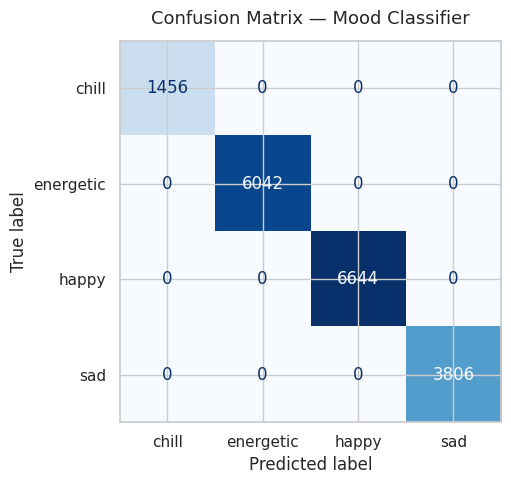

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    ax=ax,
    colorbar=False,
    cmap="Blues",
)
ax.set_title("Confusion Matrix — Mood Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=150)
plt.show()

## 7. Feature Importances

Available for tree-based estimators. Guards against `AttributeError` for other model families.

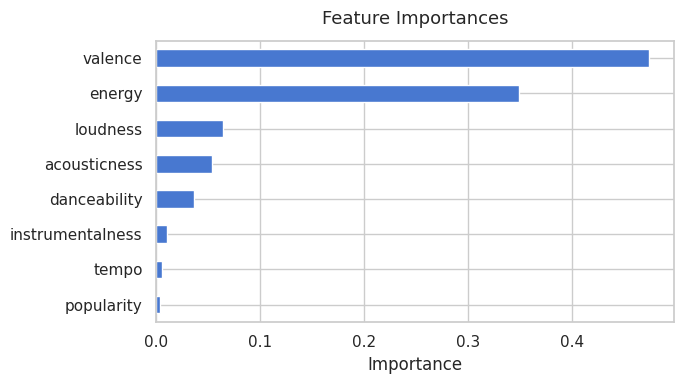

In [10]:
clf = best_pipeline.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importance = (
        pd.Series(clf.feature_importances_, index=FEATURES)
          .sort_values()
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    importance.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[0])
    ax.set_title("Feature Importances", fontsize=13, pad=12)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../models/feature_importances.png", dpi=150)
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_.")

## 8. Model Serialization

> The **full pipeline** (scaler + classifier) is persisted — not just the model weights. The Flask app can then call `pipeline.predict(X)` directly, with no manual preprocessing required at inference time.

In [12]:
joblib.dump(best_pipeline, MODEL_PATH)

print(f"\u2705  Pipeline saved  → {MODEL_PATH}")
print(f"    Model  : {best_name}")
print(f"    CV F1  : {results_df.loc[best_name, 'mean_f1']:.4f} "
      f"\u00b1 {results_df.loc[best_name, 'std_f1']:.4f}")

✅  Pipeline saved  → /home/viperdb3/PycharmProjects/moodify/models/mood_classifier.pkl
    Model  : RandomForest
    CV F1  : 1.0000 ± 0.0000
